In [49]:
%%javascript
function ClickConnect(){
console.log("Working");
document.querySelector("colab-toolbar-button#connect").click()
}setInterval(ClickConnect,60000)

<IPython.core.display.Javascript object>

In [50]:
# Importing only the read_csv and DataFrame functions from the pandas library
# - read_csv: used for reading CSV (comma-separated values) files into a DataFrame
# - DataFrame: used to create and work with tabular data structures
from pandas import read_csv, DataFrame

# Importing figure_factory module from plotly
# This is used to create interactive and visually appealing charts/plots
from plotly import figure_factory

# Importing StandardScaler from sklearn.preprocessing
# StandardScaler transforms features by removing the mean and scaling them to unit variance
# This ensures all features are on the same scale before applying machine learning models
from sklearn.preprocessing import StandardScaler

# Importing the linear_model module from sklearn
# This module contains different types of linear regression algorithms
from sklearn import linear_model

# Importing GridSearchCV from sklearn.model_selection
# GridSearchCV is used to tune model parameters by testing different combinations through cross-validation
from sklearn.model_selection import GridSearchCV

# Importing pandas library as pd (a common short alias)
# This allows us to use other pandas functions not imported earlier (like .head(), .merge(), etc.)
import pandas as pd

# Importing the warnings library to control warning messages
import warnings

# Ignoring all warning messages to keep the output clean
warnings.filterwarnings('ignore')


In [51]:
# Reading the CSV file named 'EVChargingStationUsage1.csv' located in the '/content/' folder
# The data will be stored in a pandas DataFrame called 'df' for further analysis and processing
df = read_csv('/content/EVChargingStationUsage.csv')

In [52]:
# Displaying a concise summary of the DataFrame 'df'
# It shows: number of rows, number of columns, column names, data types, and memory usage
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 259415 entries, 0 to 259414
Data columns (total 33 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   Station Name                     259415 non-null  object 
 1   MAC Address                      259415 non-null  object 
 2   Org Name                         259415 non-null  object 
 3   Start Date                       259415 non-null  object 
 4   Start Time Zone                  259415 non-null  object 
 5   End Date                         259415 non-null  object 
 6   End Time Zone                    259415 non-null  object 
 7   Transaction Date (Pacific Time)  259206 non-null  object 
 8   Total Duration (hh:mm:ss)        259415 non-null  object 
 9   Charging Time (hh:mm:ss)         259415 non-null  object 
 10  Energy (kWh)                     259415 non-null  float64
 11  GHG Savings (kg)                 259415 non-null  float64
 12  Ga

In [53]:
# This function is a pandas method that generates descriptive statistics
# (like count, mean, std deviation, min, max, and percentiles) of the numeric columns in the DataFrame `df`.
# This method is typically used to get a quick summary of the dataset to understand its distribution and key statistics.
df.describe()

,Energy (kWh),GHG Savings (kg),Gasoline Savings (gallons),Port Number,EVSE ID,Postal Code,Latitude,Longitude,Fee,Plug In Event Id,Driver Postal Code,System S/N
count,259415.000000,259415.000000,259415.000000,259415.000000,1.804670e+05,259415.000000,259415.000000,259415.000000,259415.000000,2.594150e+05,251013.000000,1.804670e+05
mean,8.544277,3.588596,1.072306,1.591627,1.462973e+05,94302.315768,37.439565,-122.151264,1.097481,1.188685e+08,94170.308255,1.443911e+11
std,7.185462,3.017894,0.901776,0.491534,2.429677e+05,1.941657,0.009621,0.015382,1.934408,4.057750e+08,4249.837126,2.483968e+10
min,0.010000,0.004000,0.001000,1.000000,3.792000e+03,94301.000000,37.422104,-122.163239,0.000000,1.000000e+00,1013.000000,1.020000e+11
25%,3.784000,1.589000,0.475000,1.000000,4.358300e+04,94301.000000,37.428318,-122.162170,0.000000,1.573000e+03,94087.000000,1.231100e+11
50%,6.868634,2.885000,0.862000,2.000000,1.074270e+05,94301.000000,37.444489,-122.158272,0.000000,3.573000e+03,94304.000000,1.427410e+11
75%,11.458340,4.813000,1.438000,2.000000,1.745590e+05,94303.000000,37.446613,-122.145699,1.640000,6.340000e+03,94804.000000,1.707410e+11
max,97.360000,40.891000,12.219000,2.000000,5.535441e+06,94306.000000,37.449375,-122.112480,84.560000,1.609436e+09,99354.000000,2.002410e+11


In [54]:
df.info() # To get details like column names , rows, and datatypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 259415 entries, 0 to 259414
Data columns (total 33 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   Station Name                     259415 non-null  object 
 1   MAC Address                      259415 non-null  object 
 2   Org Name                         259415 non-null  object 
 3   Start Date                       259415 non-null  object 
 4   Start Time Zone                  259415 non-null  object 
 5   End Date                         259415 non-null  object 
 6   End Time Zone                    259415 non-null  object 
 7   Transaction Date (Pacific Time)  259206 non-null  object 
 8   Total Duration (hh:mm:ss)        259415 non-null  object 
 9   Charging Time (hh:mm:ss)         259415 non-null  object 
 10  Energy (kWh)                     259415 non-null  float64
 11  GHG Savings (kg)                 259415 non-null  float64
 12  Ga

In [55]:
df.isnull().any() # To get the details for missing values

,0
Station Name,False
MAC Address,False
Org Name,False
Start Date,False
Start Time Zone,False
End Date,False
End Time Zone,False
Transaction Date (Pacific Time),True
Total Duration (hh:mm:ss),False
Charging Time (hh:mm:ss),False


In [56]:
# Calculate and display the number of missing values for each column in the DataFrame `df`
print(df.isnull().sum())

Station Name                           0
MAC Address                            0
Org Name                               0
Start Date                             0
Start Time Zone                        0
End Date                               0
End Time Zone                          0
Transaction Date (Pacific Time)      209
Total Duration (hh:mm:ss)              0
Charging Time (hh:mm:ss)               0
Energy (kWh)                           0
GHG Savings (kg)                       0
Gasoline Savings (gallons)             0
Port Type                              9
Port Number                            0
Plug Type                              0
EVSE ID                            78948
Address 1                              0
City                                   0
State/Province                         0
Postal Code                            0
Country                                0
Latitude                               0
Longitude                              0
Currency        

In [57]:
df['Currency'].fillna('USD', inplace=True)

In [58]:
df['Ended By'].fillna('Unknown', inplace=True)

In [59]:
df['County'].fillna('United States', inplace=True)

In [60]:
df['Transaction Date (Pacific Time)'].fillna(df['End Date'], inplace=True)

In [61]:
# Calculate and display the number of missing values for each column in the DataFrame `df`
print(df.isnull().sum())

Station Name                           0
MAC Address                            0
Org Name                               0
Start Date                             0
Start Time Zone                        0
End Date                               0
End Time Zone                          0
Transaction Date (Pacific Time)        0
Total Duration (hh:mm:ss)              0
Charging Time (hh:mm:ss)               0
Energy (kWh)                           0
GHG Savings (kg)                       0
Gasoline Savings (gallons)             0
Port Type                              9
Port Number                            0
Plug Type                              0
EVSE ID                            78948
Address 1                              0
City                                   0
State/Province                         0
Postal Code                            0
Country                                0
Latitude                               0
Longitude                              0
Currency        

In [62]:
# Converting the "Start Date" column into datetime format.
# infer_datetime_format=True: automatically detects the date format for faster and more accurate conversion
df["Start Date"] = pd.to_datetime(df["Start Date"], errors="coerce", infer_datetime_format=True)
# Creating a new column called "Date" from "Start Date
df["Date"] = df["Start Date"].dt.normalize()

In [63]:
# Importing pandas for data manipulation and requests for making API calls
import pandas as pd
import requests

# Converting "Transaction Date (Pacific Time)" column into datetime format
# Adding a new helper column "Weather_Hour" by flooring (rounding down) to the nearest hour
# This helps align EV transaction timestamps with hourly weather data
df["Transaction Date (Pacific Time)"] = pd.to_datetime(df["Transaction Date (Pacific Time)"], errors="coerce")
df["Weather_Hour"] = df["Transaction Date (Pacific Time)"].dt.floor("H")

# Getting the minimum and maximum dates from the dataset
# These will be used as start and end dates when calling the weather API
start_date = df["Weather_Hour"].min().strftime("%Y-%m-%d")
end_date = df["Weather_Hour"].max().strftime("%Y-%m-%d")
# Setting up the base URL for the Open-Meteo archive API
lat, lon = 37.4419, -122.1430
url = "https://archive-api.open-meteo.com/v1/archive"

# Defining parameters for the API request:
# - latitude & longitude: location of interest
# - start_date & end_date: date range to fetch data
# - hourly: list of weather features to fetch (temperature, humidity, wind, etc.)
# - timezone: ensures weather timestamps match local time (Pacific Time here)
params = {
    "latitude": lat,
    "longitude": lon,
    "start_date": start_date,
    "end_date": end_date,
    "hourly": "temperature_2m,relativehumidity_2m,precipitation,windspeed_10m,"
              "winddirection_10m,cloudcover",
    "timezone": "America/Los_Angeles"
}

# Sending a GET request to the weather API with the defined parameters
# Converting the response into JSON format
response = requests.get(url, params=params)
weather_data = response.json()

# Creating a DataFrame from the hourly weather data
weather_df = pd.DataFrame(weather_data["hourly"])

# Converting the "time" column into datetime format and setting it as index
# This aligns the weather data by hour
weather_df["Weather_Hour"] = pd.to_datetime(weather_df["time"])
weather_df.set_index("Weather_Hour", inplace=True)

# Dropping the original "time" column since we now use "Weather_Hour"
weather_df.drop(columns=["time"], inplace=True)

# Mapping weather data into the EV dataset using the aligned "Weather_Hour"
# For each weather feature (temperature, humidity, etc.), we attach its value to the corresponding EV transaction hour
for col in weather_df.columns:
    df[col] = df["Weather_Hour"].map(weather_df[col])

# Filling missing weather values in the dataset
# First using forward fill (ffill), then backward fill (bfill) as backup
# This ensures there are no gaps in weather data
weather_cols = weather_df.columns.tolist()
df[weather_cols] = df[weather_cols].fillna(method="ffill").fillna(method="bfill")

# Dropping the helper column "Weather_Hour" as it's no longer needed
df.drop(columns=["Weather_Hour"], inplace=True)

# Saving the final dataset (original EV data + added weather features) into a new CSV file
df.to_csv("EV_Data_OriginalPlusWeather.csv", index=False)

# Printing confirmation message once the process is complete
print("✅ Final file created with original data + weather features.")


✅ Final file created with original data + weather features.


In [64]:
# Reading the CSV file "EV_Data_OriginalPlusWeather.csv" from the '/content/' folder
# The data (which now contains both original EV data and added weather features)
# is loaded into a new DataFrame called 'df1' for further use or analysis
df1 = read_csv('/content/EV_Data_OriginalPlusWeather.csv')

In [65]:
# Displaying a quick summary of the DataFrame 'df1'
# It shows:
# - Total number of rows and columns
# - Column names and their data types
# - Count of non-null (non-missing) values per column
# - Memory usage of the DataFrame
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 259415 entries, 0 to 259414
Data columns (total 40 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   Station Name                     259415 non-null  object 
 1   MAC Address                      259415 non-null  object 
 2   Org Name                         259415 non-null  object 
 3   Start Date                       259415 non-null  object 
 4   Start Time Zone                  259415 non-null  object 
 5   End Date                         259415 non-null  object 
 6   End Time Zone                    259415 non-null  object 
 7   Transaction Date (Pacific Time)  259415 non-null  object 
 8   Total Duration (hh:mm:ss)        259415 non-null  object 
 9   Charging Time (hh:mm:ss)         259415 non-null  object 
 10  Energy (kWh)                     259415 non-null  float64
 11  GHG Savings (kg)                 259415 non-null  float64
 12  Ga

In [66]:
# Creating a new column 'Station Name_update' from the existing 'Station Name' column
# - .str.split('/') → splits the station name wherever a '/' appears
# - .str.strip() → removes any extra spaces before or after the text
df1['Station Name_update'] = df1['Station Name'].str.split('/').str[-1].str.strip()

In [67]:
# Displaying all the unique values from the column 'Station Name_update'
# This helps check the different station names present after cleaning and updating
df1['Station Name_update'].unique()

array(['HAMILTON #1', 'HAMILTON #2', 'HIGH #4', 'BRYANT #2', 'BRYANT #1',
       'MPL #4', 'MPL #6', 'MPL #2', 'MPL #1', 'MPL #5', 'MPL #3',
       'RINCONADA LIB 2', 'RINCONADA LIB 1', 'RINCONADA LIB 3',
       'WEBSTER #1', 'HIGH #1', 'WEBSTER #2', 'TED THOMPSON #1',
       'CAMBRIDGE #1', 'BRYANT #3', 'WEBSTER #3', 'CAMBRIDGE #2',
       'HIGH #2', 'HIGH #3', 'BRYANT #6', 'BRYANT #4', 'BRYANT #5',
       'TED THOMPSON #4', 'TED THOMPSON #3', 'CAMBRIDGE #5',
       'TED THOMPSON #2', 'CAMBRIDGE #3', 'CAMBRIDGE #4', 'BRYANT # 1',
       'SHERMAN 6', 'SHERMAN 7', 'SHERMAN 9', 'SHERMAN 8', 'SHERMAN 4',
       'SHERMAN 1', 'SHERMAN 3', 'SHERMAN 14', 'SHERMAN 2', 'SHERMAN 5',
       'SHERMAN 15', 'SHERMAN 11', 'SHERMAN 17'], dtype=object)

In [68]:
# Importing pandas for data handling and parser from dateutil for flexible date parsing
import pandas as pd
from dateutil import parser


# Defining a custom function to parse dates automatically
# - It tries to interpret any given value as a date using parser.parse
# - fuzzy=True: allows ignoring unknown text/noise in the string (e.g., "2020-01-01 text")
# - If parsing fails, it returns NaT (Not a Time) instead of throwing an error
def auto_parse_date(val):
    try:
        return parser.parse(str(val), fuzzy=True)
    except:
        return pd.NaT


# Applying the parsing function to the 'Start Date' column in df1
# Creates a new column 'Date Cleaned' with properly parsed datetime values
df1['Date Cleaned'] = df1['Start Date'].apply(auto_parse_date)


# Extracting different date/time components from 'Date Cleaned' for analysis
# - 'Year' → year part of the date
# - 'Month' → month part of the date
# - 'Day' → day of the month
# - 'Hour' → hour of the day (0–23)
# - 'Weekday' → day of the week (0 = Monday, 6 = Sunday)
# - 'Is Weekend' → boolean column, True if the day is Saturday(5) or Sunday(6)
df1['Year'] = df1['Date Cleaned'].dt.year
df1['Month'] = df1['Date Cleaned'].dt.month
df1['Day'] = df1['Date Cleaned'].dt.day
df1['Hour'] = df1['Date Cleaned'].dt.hour


# Printing a quick summary to check parsing quality
# - Total number of rows in the dataset
# - Count of missing values in the original 'Start Date'
# - Count of missing values in the cleaned 'Date Cleaned' column after parsing
print("Total rows:", len(df1))
print("Missing in raw:", df1['Start Date'].isna().sum())
print("Missing after parsing:", df1['Date Cleaned'].isna().sum())

Total rows: 259415
Missing in raw: 0
Missing after parsing: 0


In [69]:
# Create a simplified 'Location' column for aggregation
# Copying the cleaned station name ('Station Name_update') into a new column called 'Location'
df1['Location'] = df1['Station Name_update']


# Prepare MONTHLY data (grouped per Location)

# Dropping rows where 'End Date' is missing, since we need it for time-based analysis
df1 = df1.dropna(subset=['End Date'])

# Converting 'End Date' column into proper datetime format
# errors='coerce': invalid entries will become NaT (missing)
df1['End Date'] = pd.to_datetime(df1['End Date'], errors='coerce')

# Creating a new column 'DateOnly' by flooring 'End Date' to the nearest day
# This removes the time part and keeps only the date (YYYY-MM-DD)
df1['DateOnly'] = df1['End Date'].dt.floor('D')


# Grouping by Location and DateOnly, summing up 'Energy (kWh)' for each day
# Renaming the resulting column to 'daily_kwh'
daily = (
    df1.groupby(['Location', 'DateOnly'], as_index=False)['Energy (kWh)']
       .sum()
       .rename(columns={'Energy (kWh)':'daily_kwh'})
)

# Monthly rollup from daily totals
# Creating 'YM' (Year-Month) column from DateOnly for monthly grouping
daily['YM'] = daily['DateOnly'].dt.to_period('M')

# Grouping daily data by Location and Year-Month
# - avg_load_kwh: average daily load across the month
# - total_load_kwh: total kWh in the month
# - peak_load_kwh: maximum daily kWh observed in that month
monthly_core = (
    daily.groupby(['Location','YM'], as_index=False)
         .agg(
              load_kwh=('daily_kwh','sum'),
              peak_load_kwh=('daily_kwh','max'))
)

# Monthly average weather data per location ---
# Selecting weather-related columns that were merged earlier from the API
weather_cols = [
    'temperature_2m','relativehumidity_2m','precipitation','windspeed_10m',
    'winddirection_10m','cloudcover'
]

# Creating 'YM' (Year-Month) column in df1 for weather aggregation
df1['YM'] = df1['DateOnly'].dt.to_period('M')

# Grouping weather data by Location and Year-Month
# Taking the mean (average) of each weather parameter across the month
w_monthly = (
    df1.groupby(['Location','YM'], as_index=False)[weather_cols]
       .mean()
)

# Merging monthly energy data with monthly weather data on Location and YM
# 'how="left"': keep all energy rows, even if weather data is missing
monthly = monthly_core.merge(w_monthly, on=['Location','YM'], how='left')

# Extracting numeric Year and Month from the YM (Year-Month) period
monthly['Year'] = monthly['YM'].dt.year
monthly['Month'] = monthly['YM'].dt.month

In [70]:
# Saving the final monthly dataset (with both energy + weather features) into a CSV file
# - "EV_Data_Final.csv" will be the output file name
# - index=False ensures pandas does not add extra row numbers as a separate column in the CSV
monthly.to_csv("EV_Data_Final.csv", index=False)

# Printing a confirmation message once the file is successfully created
print("✅ Final file created with original data + weather features.")

✅ Final file created with original data + weather features.


In [71]:
# Reading the saved CSV file "EV_Data_Final.csv" back into a new DataFrame called 'monthly_df'
# This loads the final processed dataset (energy + weather features at monthly level) for further use
monthly_df = pd.read_csv("EV_Data_Final.csv")

# Displaying a concise summary of 'monthly_df'
# It shows:
# - Number of rows and columns
# - Column names and their data types
# - Count of non-null (non-missing) values per column
# - Memory usage of the DataFrame
monthly_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2284 entries, 0 to 2283
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Location             2284 non-null   object 
 1   YM                   2284 non-null   object 
 2   load_kwh             2284 non-null   float64
 3   peak_load_kwh        2284 non-null   float64
 4   temperature_2m       2284 non-null   float64
 5   relativehumidity_2m  2284 non-null   float64
 6   precipitation        2284 non-null   float64
 7   windspeed_10m        2284 non-null   float64
 8   winddirection_10m    2284 non-null   float64
 9   cloudcover           2284 non-null   float64
 10  Year                 2284 non-null   int64  
 11  Month                2284 non-null   int64  
dtypes: float64(8), int64(2), object(2)
memory usage: 214.3+ KB


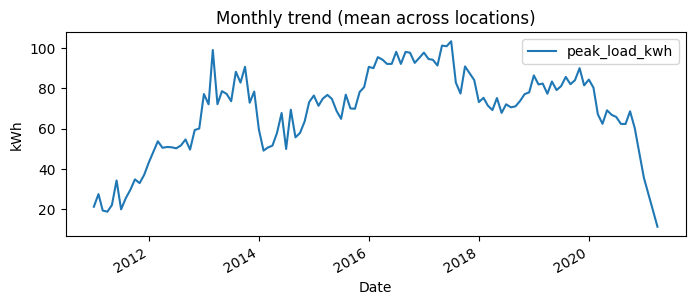

In [72]:
import pandas as pd, matplotlib.pyplot as plt

monthly = monthly_df.copy()
monthly['date'] = pd.to_datetime(dict(year=monthly['Year'], month=monthly['Month'], day=1))

g = monthly.sort_values('date').groupby('date')[['peak_load_kwh']].mean()
g.plot(figsize=(8,3))
plt.title('Monthly trend (mean across locations)')
plt.ylabel('kWh'); plt.xlabel('Date'); plt.show()

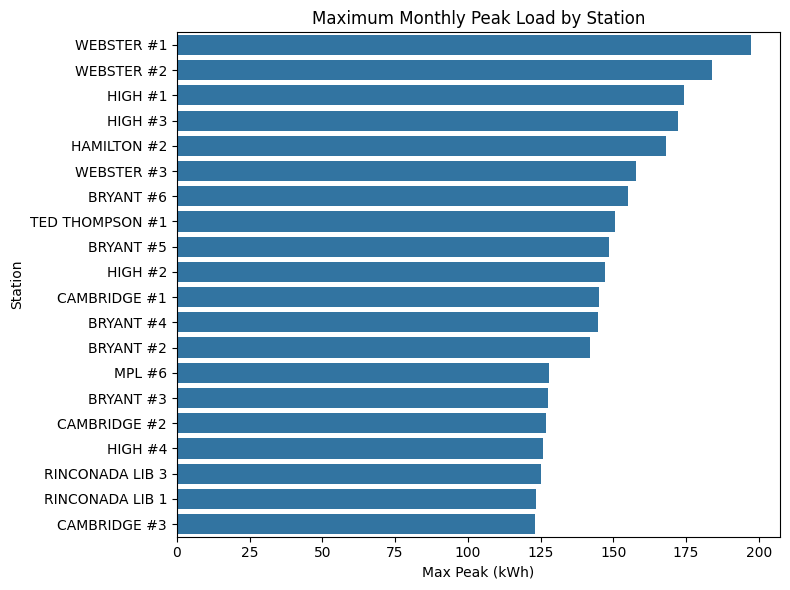

In [73]:
import seaborn as sns
# number of stations to display
TOP_N = 20   # change to None to show all (can get cluttered)

# ---- Maximum monthly peak load per station ----
agg_max = (monthly_df.groupby('Location', as_index=False)['peak_load_kwh']
           .max()
           .rename(columns={'peak_load_kwh':'max_peak_kwh'})
           .sort_values('max_peak_kwh', ascending=False))

plt.figure(figsize=(8, 6))
sns.barplot(data=agg_max.head(TOP_N) if TOP_N else agg_max,
            x='max_peak_kwh', y='Location')
plt.title('Maximum Monthly Peak Load by Station')
plt.xlabel('Max Peak (kWh)'); plt.ylabel('Station')
plt.tight_layout(); plt.show()

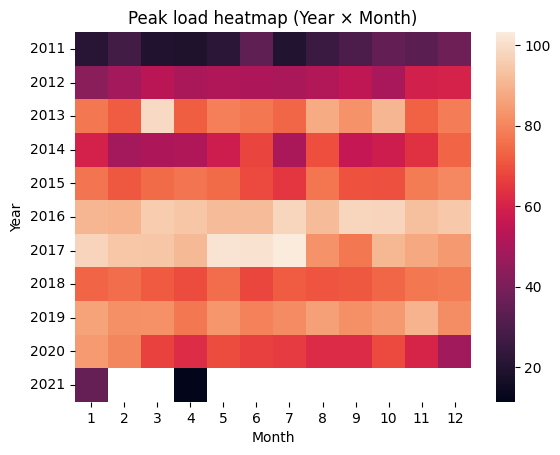

In [74]:
import seaborn as sns, matplotlib.pyplot as plt
p = monthly.pivot_table(index='Year', columns='Month', values='peak_load_kwh', aggfunc='mean')
sns.heatmap(p, annot=False)
plt.title('Peak load heatmap (Year × Month)'); plt.ylabel('Year'); plt.xlabel('Month'); plt.show()

In [75]:
# Defining a function 'get_season' that takes a month number (1–12) and returns the corresponding season
def get_season(Month):
    if Month in [12, 1, 2]:
        return "Winter"
    elif Month in [3, 4, 5]:
        return "Spring"
    elif Month in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"

# Applying the 'get_season' function to the 'Month' column of monthly_df
# Creates a new column 'Season' that stores the season for each row
monthly_df["Season"] = monthly_df["Month"].apply(get_season)

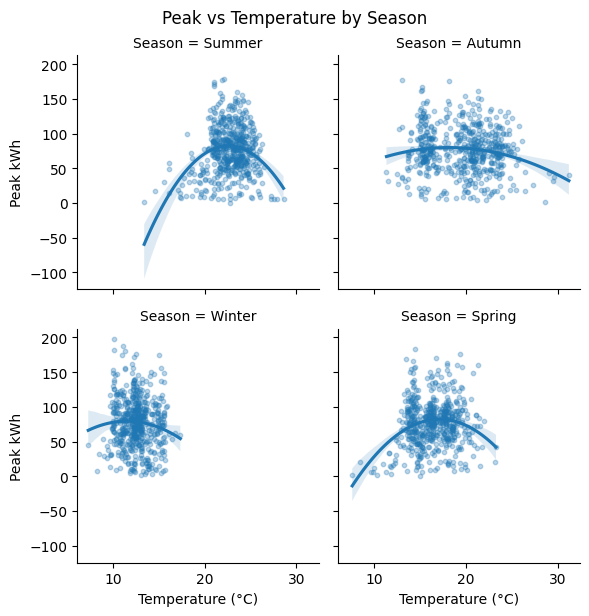

In [76]:
import pandas as pd, seaborn as sns, matplotlib.pyplot as plt
def season_from_month(m):
    return 'Winter' if m in [12,1,2] else 'Spring' if m in [3,4,5] else 'Summer' if m in [6,7,8] else 'Autumn'
monthly['Season'] = monthly['Month'].apply(season_from_month)
g = sns.lmplot(x='temperature_2m', y='peak_load_kwh', col='Season', col_wrap=2,
               data=monthly, scatter_kws={'s':10, 'alpha':0.3}, order=2, height=3)
g.set_axis_labels('Temperature (°C)', 'Peak kWh'); plt.suptitle('Peak vs Temperature by Season', y=1.02); plt.show()

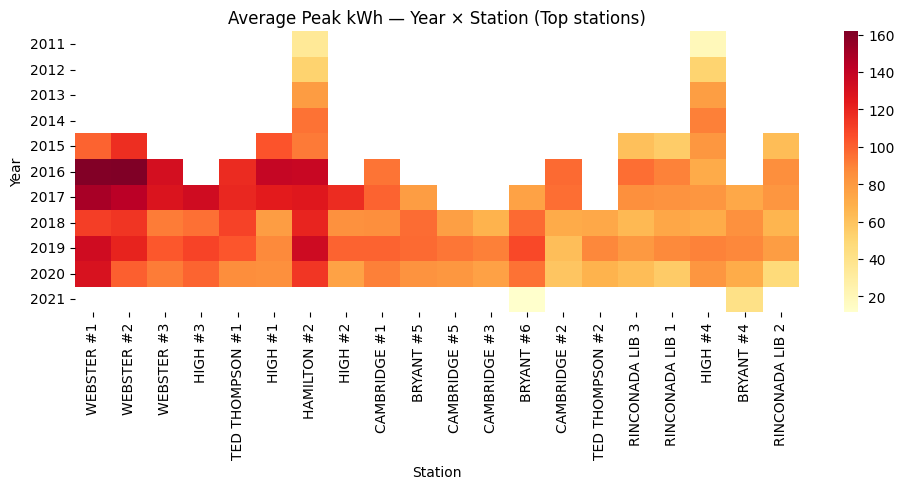

In [77]:
import pandas as pd, seaborn as sns, matplotlib.pyplot as plt

TOP_N = 20  # change as you like

# 1) find top-N stations by average peak
top_locs = (monthly_df.groupby('Location')['peak_load_kwh']
            .mean().nlargest(TOP_N).index)

# 2) pivot Year × Location for those stations
p = (monthly_df[monthly_df['Location'].isin(top_locs)]
     .pivot_table(index='Year', columns='Location',
                  values='peak_load_kwh', aggfunc='mean'))

# optional: order stations by overall mean peak
p = p[p.mean().sort_values(ascending=False).index]

plt.figure(figsize=(10, 5))
sns.heatmap(p, cmap='YlOrRd')
plt.title('Average Peak kWh — Year × Station (Top stations)')
plt.xlabel('Station'); plt.ylabel('Year')
plt.tight_layout(); plt.show()


In [78]:
monthly_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2284 entries, 0 to 2283
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Location             2284 non-null   object 
 1   YM                   2284 non-null   object 
 2   load_kwh             2284 non-null   float64
 3   peak_load_kwh        2284 non-null   float64
 4   temperature_2m       2284 non-null   float64
 5   relativehumidity_2m  2284 non-null   float64
 6   precipitation        2284 non-null   float64
 7   windspeed_10m        2284 non-null   float64
 8   winddirection_10m    2284 non-null   float64
 9   cloudcover           2284 non-null   float64
 10  Year                 2284 non-null   int64  
 11  Month                2284 non-null   int64  
 12  Season               2284 non-null   object 
dtypes: float64(8), int64(2), object(3)
memory usage: 232.1+ KB


In [79]:
# Converting the categorical column 'Season' into dummy/indicator variables (one-hot encoding)
# - pd.get_dummies(): creates new binary columns for each category (Spring, Summer, Fall, etc.)
# - drop_first=True: drops the first category (e.g., Winter) to avoid the dummy variable trap (multicollinearity)
# The updated DataFrame (with new dummy columns) is stored back into 'monthly_df'
monthly_df = pd.get_dummies(monthly_df, columns=['Season'], drop_first=True)

In [80]:
monthly_df['Season_Summer'].unique()

array([ True, False])

In [81]:
monthly_df["Season_Summer"] = monthly_df["Season_Summer"].map({False: 0, True: 1})

In [82]:
monthly_df['Season_Winter'].unique()

array([False,  True])

In [83]:
monthly_df["Season_Winter"] = monthly_df["Season_Winter"].map({False: 0, True: 1})

In [84]:
monthly_df['Season_Spring'].unique()

array([False,  True])

In [85]:
monthly_df["Season_Spring"] = monthly_df["Season_Spring"].map({False: 0, True: 1})

In [86]:
monthly_df['Location'].unique()

array(['BRYANT # 1', 'BRYANT #1', 'BRYANT #2', 'BRYANT #3', 'BRYANT #4',
       'BRYANT #5', 'BRYANT #6', 'CAMBRIDGE #1', 'CAMBRIDGE #2',
       'CAMBRIDGE #3', 'CAMBRIDGE #4', 'CAMBRIDGE #5', 'HAMILTON #1',
       'HAMILTON #2', 'HIGH #1', 'HIGH #2', 'HIGH #3', 'HIGH #4',
       'MPL #1', 'MPL #2', 'MPL #3', 'MPL #4', 'MPL #5', 'MPL #6',
       'RINCONADA LIB 1', 'RINCONADA LIB 2', 'RINCONADA LIB 3',
       'SHERMAN 1', 'SHERMAN 11', 'SHERMAN 14', 'SHERMAN 15',
       'SHERMAN 17', 'SHERMAN 2', 'SHERMAN 3', 'SHERMAN 4', 'SHERMAN 5',
       'SHERMAN 6', 'SHERMAN 7', 'SHERMAN 8', 'SHERMAN 9',
       'TED THOMPSON #1', 'TED THOMPSON #2', 'TED THOMPSON #3',
       'TED THOMPSON #4', 'WEBSTER #1', 'WEBSTER #2', 'WEBSTER #3'],
      dtype=object)

In [87]:
# makes 1 column per location; values 0/1
monthly_df = pd.get_dummies(
    monthly_df, columns=['Location'], prefix='loc', dtype='int8'
)

In [88]:
monthly_df.drop(['YM'], axis=1, inplace=True)

In [89]:
monthly_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2284 entries, 0 to 2283
Data columns (total 60 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   load_kwh             2284 non-null   float64
 1   peak_load_kwh        2284 non-null   float64
 2   temperature_2m       2284 non-null   float64
 3   relativehumidity_2m  2284 non-null   float64
 4   precipitation        2284 non-null   float64
 5   windspeed_10m        2284 non-null   float64
 6   winddirection_10m    2284 non-null   float64
 7   cloudcover           2284 non-null   float64
 8   Year                 2284 non-null   int64  
 9   Month                2284 non-null   int64  
 10  Season_Spring        2284 non-null   int64  
 11  Season_Summer        2284 non-null   int64  
 12  Season_Winter        2284 non-null   int64  
 13  loc_BRYANT # 1       2284 non-null   int8   
 14  loc_BRYANT #1        2284 non-null   int8   
 15  loc_BRYANT #2        2284 non-null   i

In [90]:
# Setting target columns (what we want to predict later)
targets = ['peak_load_kwh']     # don't cap targets here

# Defining columns to skip from outlier treatment:
# - target variables (avg_load_kwh, peak_load_kwh)
# - time columns (Year, Month)
# - dummy variables for Season
# - categorical identifier (Location)
skip_cols = targets + ['Year', 'Month', 'Season_Spring', 'Season_Summer', 'Season_Winter', 'Location']


# Selecting continuous numeric columns to check for outliers
# - First get all numeric columns
num_cols = monthly_df.select_dtypes(include=['number']).columns.tolist()

# - Keep only numeric columns that are not in skip_cols
# - Also filter to those with more than 10 unique values (to avoid binary/dummy columns)
cont_cols = [c for c in num_cols if c not in skip_cols and monthly_df[c].nunique() > 10]

print("Continuous columns considered:", cont_cols)


# --- Fit IQR thresholds on the FULL DATA (pre-split) ---

# Note: pre-split capping can leak information,
# but using robust statistics (IQR, medians) minimizes this risk.

k = 1.5  # can set to 3.0 to be more conservative with outliers

# Q1 (25th percentile), Q3 (75th percentile), and IQR (interquartile range)
Q1 = monthly_df[cont_cols].quantile(0.25)
Q3 = monthly_df[cont_cols].quantile(0.75)
IQR = Q3 - Q1

# Lower and upper bounds for outlier detection
lower = Q1 - k * IQR
upper = Q3 + k * IQR

# Storing caps in a DataFrame for reference
caps = pd.DataFrame({'lower': lower, 'upper': upper})
print("\nIQR caps (first rows):\n", caps.head())


# --- Outlier summary BEFORE capping ---

# Function to count outliers below/above bounds for each column
def outlier_summary(d, cols, lo, hi):
    n = len(d)
    out = []
    for c in cols:
        below = int((d[c] < lo[c]).sum())   # count of values below lower bound
        above = int((d[c] > hi[c]).sum())   # count of values above upper bound
        out.append([c, below, above, below+above, (below+above)*100.0/n])
    return pd.DataFrame(out, columns=['column','below','above','total','pct_rows']) \
             .sort_values('pct_rows', ascending=False)

print("\n=== Outliers BEFORE capping ===")
print(outlier_summary(monthly_df, cont_cols, lower, upper).head(10).to_string(index=False))



# Copy dataset to a new DataFrame before modifying
df_capped = monthly_df.copy()

# For each continuous column, clip values to the lower/upper thresholds
for c in cont_cols:
    df_capped[c] = df_capped[c].clip(lower[c], upper[c])


# --- Enforce physical bounds for some weather sensors (optional) ---

phys_bounds = {
    'relativehumidity_2m': (0, 100),  # humidity % must be between 0 and 100
    'cloudcover': (0, 100),           # cloud cover % must be between 0 and 100
    'winddirection_10m': (0, 360),    # wind direction must be between 0 and 360 degrees
    'precipitation': (0, None)        # precipitation cannot be negative
}

# Apply these physical limits on top of IQR caps
for c, (lo, hi) in phys_bounds.items():
    if c in df_capped.columns:
        df_capped[c] = df_capped[c].clip(lower=lo, upper=hi if hi is not None else df_capped[c].max())


# --- Check how many values were actually changed (sanity check) ---

# Compare original vs capped dataset, count number of modified values per column
changed = pd.Series({c: int((monthly_df[c] != df_capped[c]).sum()) for c in cont_cols}) \
            .sort_values(ascending=False)

print("\nValues clipped per feature (top 10):")
print(changed.head(10).to_string())

Continuous columns considered: ['load_kwh', 'temperature_2m', 'relativehumidity_2m', 'precipitation', 'windspeed_10m', 'winddirection_10m', 'cloudcover']

IQR caps (first rows):
                           lower        upper
load_kwh            -957.179375  2780.093625
temperature_2m         2.169640    33.501556
relativehumidity_2m   26.648131    95.317930
precipitation         -0.095522     0.159203
windspeed_10m          1.401488    20.029517

=== Outliers BEFORE capping ===
             column  below  above  total  pct_rows
      precipitation      0    198    198  8.669002
  winddirection_10m     40      0     40  1.751313
           load_kwh      0     25     25  1.094571
      windspeed_10m      2      2      4  0.175131
relativehumidity_2m      1      1      2  0.087566
         cloudcover      0      2      2  0.087566
     temperature_2m      0      0      0  0.000000

Values clipped per feature (top 10):
precipitation          198
winddirection_10m       40
load_kwh          

In [91]:
 df_capped.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2284 entries, 0 to 2283
Data columns (total 60 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   load_kwh             2284 non-null   float64
 1   peak_load_kwh        2284 non-null   float64
 2   temperature_2m       2284 non-null   float64
 3   relativehumidity_2m  2284 non-null   float64
 4   precipitation        2284 non-null   float64
 5   windspeed_10m        2284 non-null   float64
 6   winddirection_10m    2284 non-null   float64
 7   cloudcover           2284 non-null   float64
 8   Year                 2284 non-null   int64  
 9   Month                2284 non-null   int64  
 10  Season_Spring        2284 non-null   int64  
 11  Season_Summer        2284 non-null   int64  
 12  Season_Winter        2284 non-null   int64  
 13  loc_BRYANT # 1       2284 non-null   int8   
 14  loc_BRYANT #1        2284 non-null   int8   
 15  loc_BRYANT #2        2284 non-null   i

In [92]:
# Printing the unique years present in the capped dataset
print("Years in  df_capped:", sorted(df_capped['Year'].unique()))

# Printing the overall range of years (minimum to maximum)
print("Range:", df_capped['Year'].min(), "to", df_capped['Year'].max())


# --- Splitting the dataset into Train / Validation / Test sets ---

# Training set → data from 2011 to 2017
train_df = df_capped[(monthly_df["Year"] >= 2011) & (df_capped["Year"] <= 2017)]

# Validation set → data from 2018 to 2019
validate_df = df_capped[(monthly_df["Year"] >= 2018) & (df_capped["Year"] <= 2019)]

# Test set → data from 2020 to 2021
test_df = df_capped[(monthly_df["Year"] >= 2020) & (df_capped["Year"] <= 2021)]


# --- Final shape check for splits ---

# Printing the number of rows and columns in each split
print("Train:", train_df.shape, "Val:", validate_df.shape, "Test:", test_df.shape)

Years in  df_capped: [np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021)]
Range: 2011 to 2021
Train: (1090, 60) Val: (788, 60) Test: (406, 60)


In [93]:
# Checking the size (shape) of each dataset split
# .shape returns (number of rows, number of columns)

# Print number of rows & columns in the training dataset
print("Train set:", train_df.shape)

# Print number of rows & columns in the validation dataset
print("Validation set:", validate_df.shape)

# Print number of rows & columns in the test dataset
print("Test set:", test_df.shape)

Train set: (1090, 60)
Validation set: (788, 60)
Test set: (406, 60)


In [94]:
# --- Choose target variable ---
# Setting 'peak_load_kwh' as the prediction target (y)
# Earlier target was 'Energy (kWh)' at session level, now changed to monthly peak load
y = 'peak_load_kwh'


# --- Select features and split into train/validation/test sets ---

# List of columns to drop from features (contains the target itself)
x = ['peak_load_kwh']

# Training data
# - Features (x_train): all columns except target
# - Target (y_train): only the chosen target column
x_train = train_df.drop(columns=x)
y_train = train_df[y]

# Validation data (for model tuning)
x_val = validate_df.drop(columns=x)
y_val = validate_df[y]

# Test data (final evaluation)
x_test = test_df.drop(columns=x)
y_test = test_df[y]

**Linear Regression**

In [95]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

lin_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lin",    ElasticNet(max_iter=3000, tol=1e-3, random_state=42))
])

param_grid = {
    "lin__alpha":   [0.001, 0.01, 0.1, 1, 10, 100],
    "lin__l1_ratio":[0.2, 0.5, 0.8],
    "lin__fit_intercept": [True, False]
}

lin_search = GridSearchCV(
    estimator=lin_pipe,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=3,          # smaller CV to speed up
    n_jobs=-1,
    refit=True
)

lin_search.fit(x_train, y_train)
print("Best parameters:", lin_search.best_params_)
print("Best CV (neg RMSE):", lin_search.best_score_)


Best parameters: {'lin__alpha': 0.001, 'lin__fit_intercept': True, 'lin__l1_ratio': 0.8}
Best CV (neg RMSE): -18.279248551141592


In [96]:
# Train
best_lin = lin_search.best_estimator_
y_train_pred_l = best_lin.predict(x_train)
r2_train_l   = r2_score(y_train, y_train_pred_l)
rmse_train_l = np.sqrt(mean_squared_error(y_train, y_train_pred_l))
mae_train_l  = mean_absolute_error(y_train, y_train_pred_l)
print("Train R²:", r2_train_l)
print("Train RMSE:", rmse_train_l)
print("Train MAE:", mae_train_l)

# Validate
y_val_pred_l = best_lin.predict(x_val)
r2_val_l   = r2_score(y_val, y_val_pred_l)
rmse_val_l = np.sqrt(mean_squared_error(y_val, y_val_pred_l))
mae_val_l  = mean_absolute_error(y_val, y_val_pred_l)
print("Val R²:", r2_val_l)
print("Val RMSE:", rmse_val_l)
print("Val MAE:", mae_val_l)

Train R²: 0.8552009445701508
Train RMSE: 13.96307566591315
Train MAE: 10.731399128851464
Val R²: 0.6048383720566004
Val RMSE: 18.90404560973455
Val MAE: 15.861886242949007


In [97]:
# Check performance of linear regression on Test set
y_test_pred_l = best_lin.predict(x_test)
r2_test_l   = r2_score(y_test, y_test_pred_l)
rmse_test_l = np.sqrt(mean_squared_error(y_test, y_test_pred_l))
mae_test_l  = mean_absolute_error(y_test, y_test_pred_l)
print("Test R²:", r2_test_l)
print("Test RMSE:", rmse_test_l)
print("Test MAE:", mae_test_l)

Test R²: 0.5874337223752308
Test RMSE: 20.819305868593027
Test MAE: 16.92826689805433


In [98]:
import numpy as np
import matplotlib.pyplot as plt

def plot_actual_vs_predicted(y_true, y_pred, title="Actual vs Predicted"):
    plt.figure(figsize=(12, 6))
    n = min(100, len(y_true))              # show first 100 points
    idx = np.arange(n)
    plt.plot(idx, y_true[:n], label='Actual', marker='o', color='blue')
    plt.plot(idx, y_pred[:n], label='Predicted', marker='x', color='black')
    plt.title(title, fontsize=16)
    plt.xlabel('Sample Index')
    plt.ylabel('kWh')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

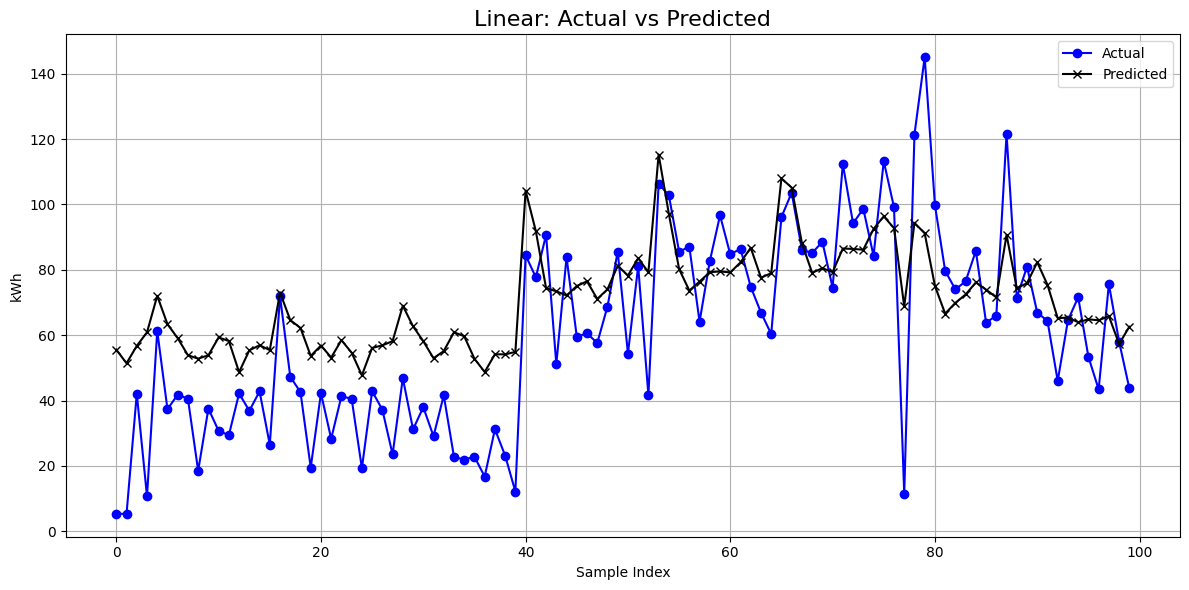

In [99]:
y_test_pred_lin = best_lin.predict(x_test)
plot_actual_vs_predicted(y_test, y_test_pred_lin, "Linear: Actual vs Predicted")

In [100]:
import numpy as np
import matplotlib.pyplot as plt

def plot_prediction_parity(y_true, y_pred, title="Prediction Parity"):
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, s=14, alpha=0.5)
    lo = min(np.min(y_true), np.min(y_pred))
    hi = max(np.max(y_true), np.max(y_pred))
    plt.plot([lo, hi], [lo, hi], 'k--', lw=1)   # 45° line
    plt.xlim(lo, hi); plt.ylim(lo, hi)
    plt.title(title)
    plt.xlabel("Actual kWh"); plt.ylabel("Predicted kWh")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

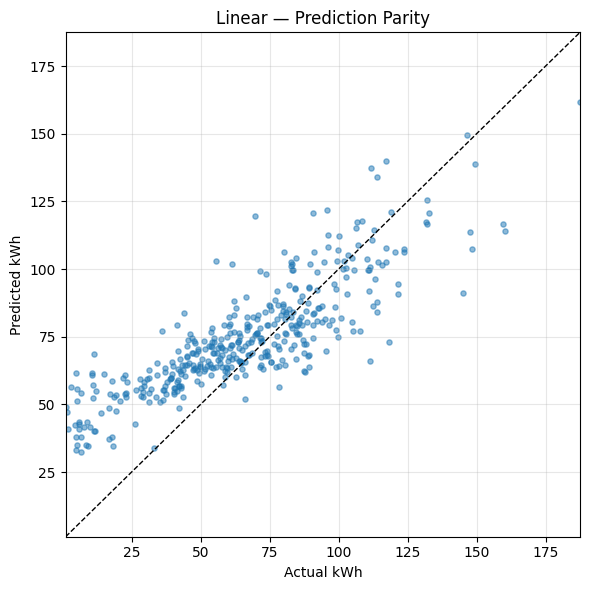

In [101]:
y_test_pred_lin = best_lin.predict(x_test)
plot_prediction_parity(y_test, y_test_pred_lin, "Linear — Prediction Parity")

**Support Vector Machine**

In [102]:
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler
# Importing Support Vector Regressor (SVR) model for regression tasks
from sklearn.svm import SVR
# Importing tools for hyperparameter tuning and cross-validation
# GridSearchCV: tries all combinations of parameters
# RandomizedSearchCV: tests random combinations (faster on large grids)
# KFold: splits data into K parts for cross-validation
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, KFold
# Importing evaluation metrics for regression models
# r2_score: measures how well predictions explain variance in data
# mean_absolute_error (MAE): average absolute difference between predicted & actual values
# mean_squared_error (MSE): average squared difference (penalizes large errors more)
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
# Importing numpy for mathematical operations (arrays, calculations, etc.)
import numpy as np

In [103]:
from mmap import MAP_EXECUTABLE
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# --- SVR with StandardScaler inside the pipeline ---
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR())
])

# Train on RAW features (scaling happens inside)
pipe.fit(x_train, y_train)

# ---- Evaluate on TRAIN (same print style) ----
y_train_pred_SVR = pipe.predict(x_train)
r2_train_SVR   = r2_score(y_train, y_train_pred_SVR)
rmse_train_SVR = np.sqrt(mean_squared_error(y_train, y_train_pred_SVR))
mae_train_SVR  = mean_absolute_error(y_train, y_train_pred_SVR)
print("Train R²:", r2_train_SVR)
print("Train RMSE:", rmse_train_SVR)
print("Train MAE:", mae_train_SVR)


Train R²: 0.51241906030755
Train RMSE: 25.62250503023738
Train MAE: 19.800071623847465


In [104]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# --- Pipeline: scale -> SVR ---
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(cache_size=2000))
])

# --- Grid for SVR
param_grid = {
    "svr__kernel":  ["linear", "poly", "rbf", "sigmoid"],
    "svr__C":       [1, 10, 100, 1000],
    "svr__epsilon": [0.001, 0.01, 0.1, 1.0],
    "svr__gamma":   ["scale", "auto"],   # used by rbf/poly/sigmoid
}

# --- GridSearchCV on TRAIN only ---
grid_search_SVR = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=10,
    n_jobs=-1,
    refit=True
)

grid_search_SVR.fit(x_train, y_train)

print("Best parameters:", grid_search_SVR.best_params_)
print("Best CV (neg RMSE):", grid_search_SVR.best_score_)

Best parameters: {'svr__C': 100, 'svr__epsilon': 1.0, 'svr__gamma': 'scale', 'svr__kernel': 'linear'}
Best CV (neg RMSE): -17.808300563681904


In [105]:
# Use tuned pipeline
best_pipe = grid_search_SVR.best_estimator_
#Evaluate on Train
y_train_pred_SVR = best_pipe.predict(x_train)
r2_train_SVR   = r2_score(y_train, y_train_pred_SVR)
rmse_train_SVR = np.sqrt(mean_squared_error(y_train, y_train_pred_SVR))
mae_train_SVR  = mean_absolute_error(y_train, y_train_pred_SVR)
print("Train R²:", r2_train_SVR)
print("Train RMSE:", rmse_train_SVR)
print("Train MAE:", mae_train_SVR)


Train R²: 0.8493334487640756
Train RMSE: 14.24316976632137
Train MAE: 10.469389294109831


In [106]:
y_val_pred_SVR = best_pipe.predict(x_val)

In [107]:
r2_val_SVR   = r2_score(y_val, y_val_pred_SVR)
rmse_val_SVR = np.sqrt(mean_squared_error(y_val, y_val_pred_SVR))
mae_val_SVR  = mean_absolute_error(y_val, y_val_pred_SVR)
print("Val R²:", r2_val_SVR)
print("Val RMSE:", rmse_val_SVR)
print("Val MAE:", mae_val_SVR)

Val R²: 0.6257083707868736
Val RMSE: 18.398076940601882
Val MAE: 15.345399580719205


In [108]:
# Check perfotmance of Support Vector regression
y_test_pred_SVR = best_pipe.predict(x_test)
r2_test_SVR = r2_score(y_test, y_test_pred_SVR)

# RMSE (Root Mean Squared Error) for validation predictions
# Penalizes large prediction errors more heavily
rmse_test_SVR = np.sqrt(mean_squared_error(y_test, y_test_pred_SVR))

# MAE (Mean Absolute Error) for validation predictions
# Measures average absolute error in same units as target
mae_test_SVR = mean_absolute_error(y_test,y_test_pred_SVR)


# Print metrics for validation set ---
print("SVR Test - Test R²:", r2_test_SVR)
print("SVR Test RMSE:", rmse_test_SVR)
print("SVR Test MAE:", mae_test_SVR)

SVR Test - Test R²: 0.6063381688204363
SVR Test RMSE: 20.336725961711657
SVR Test MAE: 16.556163600234342


In [109]:
import numpy as np
import matplotlib.pyplot as plt

def plot_actual_vs_predicted(y_true, y_pred, title="Actual vs Predicted"):
    plt.figure(figsize=(12, 6))
    n = min(100, len(y_true))              # show first 100 points
    idx = np.arange(n)
    plt.plot(idx, y_true[:n], label='Actual', marker='o', color='blue')
    plt.plot(idx, y_pred[:n], label='Predicted', marker='x', color='black')
    plt.title(title, fontsize=16)
    plt.xlabel('Sample Index')
    plt.ylabel('kWh')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

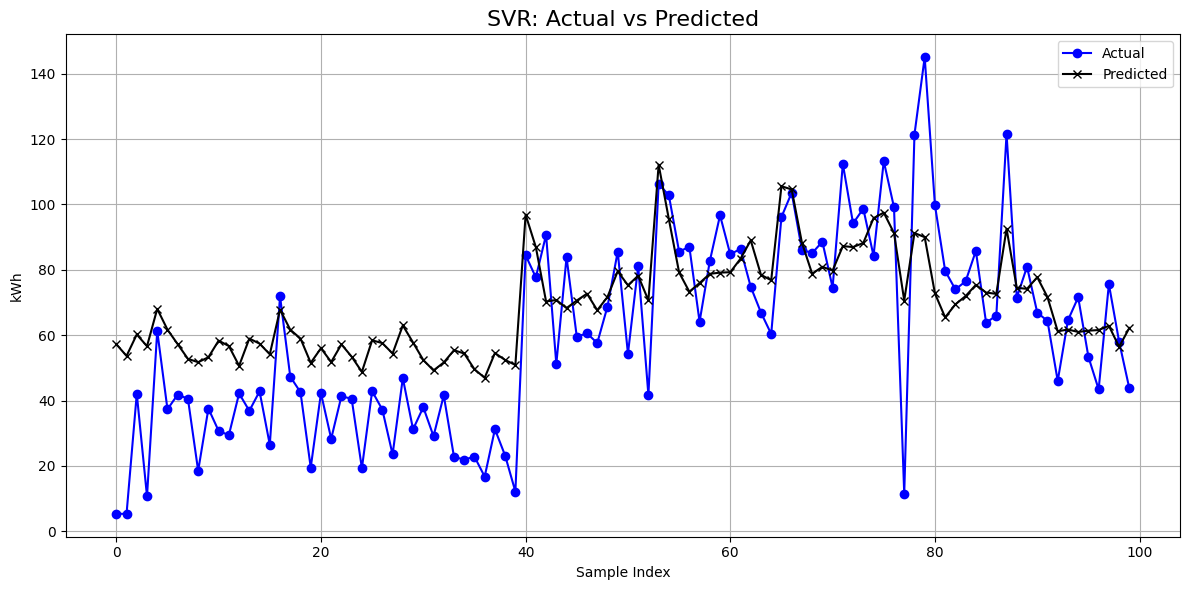

In [110]:
y_test_pred_svr = best_pipe.predict(x_test)
plot_actual_vs_predicted(y_test, y_test_pred_svr, "SVR: Actual vs Predicted")

In [111]:
import numpy as np
import matplotlib.pyplot as plt

def plot_prediction_parity(y_true, y_pred, title="Prediction Parity"):
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, s=14, alpha=0.5)
    lo = min(np.min(y_true), np.min(y_pred))
    hi = max(np.max(y_true), np.max(y_pred))
    plt.plot([lo, hi], [lo, hi], 'k--', lw=1)   # 45° line
    plt.xlim(lo, hi); plt.ylim(lo, hi)
    plt.title(title)
    plt.xlabel("Actual kWh"); plt.ylabel("Predicted kWh")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

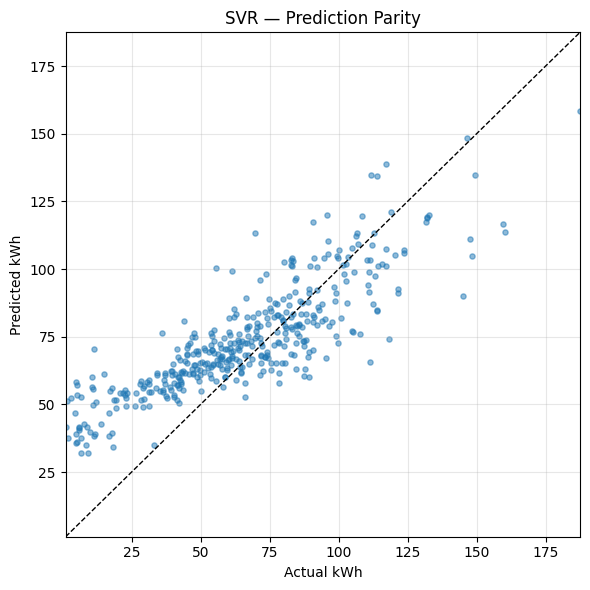

In [112]:
y_test_pred_svr = best_pipe.predict(x_test)
plot_prediction_parity(y_test, y_test_pred_svr, "SVR — Prediction Parity")

**Random Forest Regressor**

In [113]:
# Importing GridSearchCV for hyperparameter tuning via cross-validation
from sklearn.model_selection import GridSearchCV

# Importing Series constructor from pandas (not used below in this block)
from pandas import Series


# Importing the RandomForestRegressor model (tree-based ensemble method)
from sklearn.ensemble import RandomForestRegressor

# Creating a baseline RandomForestRegressor with fixed settings
# - criterion='squared_error': splits are chosen to minimize MSE
# - max_features='sqrt': each split considers sqrt(#features)
# - random_state=1: for reproducible results
RF_Regressor1 = RandomForestRegressor(criterion='squared_error', max_features='sqrt', random_state=42)

# Defining the hyperparameter grid to search over:
# - n_estimators: number of trees in the forest
# - max_features: feature subset strategy ('sqrt' or 'log2')
# - min_samples_split: minimum samples needed to split a node
# - max_depth: maximum depth allowed for each tree
# - min_samples_leaf: minimum samples required at a leaf node
no_Trees = {'n_estimators': [400,500,600,700,800],
            'max_features':['sqrt','log2'],
            'min_samples_split':[2],
            'max_depth':[8,10,12],
            'min_samples_leaf':[2,3,7]}

# Setting up GridSearchCV to find the best hyperparameters
# - estimator: the RandomForest defined above
# - param_grid: the grid of values to try
# - scoring='r2': use R² as the evaluation metric
# - cv=5: 5-fold cross-validation
grid_search4 = GridSearchCV(estimator=RF_Regressor1, param_grid=no_Trees, scoring='r2', cv=5)

# Running the grid search on the training data (features + target)
grid_search4.fit(x_train, y_train)

# Extracting the best hyperparameter combination found during CV
best_parameters = grid_search4.best_params_

# Printing the best hyperparameters
print("Best parameters: ", best_parameters)

# Getting the best cross-validated R² score achieved with those parameters
best_result = grid_search4.best_score_

# Printing the best CV score
print("best_score: ", best_result)

Best parameters:  {'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 600}
best_score:  0.48895221775335196


In [114]:
# Importing ensemble module from sklearn (contains ensemble methods like Random Forest, Gradient Boosting, etc.)
from sklearn import ensemble

# Initialize the Random Forest with the best parameters ---
# Using **best_parameters from the previous GridSearchCV results
RF2_regressor = ensemble.RandomForestRegressor(**grid_search4.best_params_,random_state=42)

# Train the Random Forest model on the training data ---
# (Note: scaling is not required for Random Forest, but using x_train_scaled won't hurt)
RF2_regressor.fit(x_train, y_train)

#  Evaluate performance on training data ---
# .score() by default returns R² (coefficient of determination)
#  1.0 = perfect fit, closer to 0 means weak fit
best_result = RF2_regressor.score(x_train, y_train)

# Print the R² score for the training dataset
print("r2: ", best_result)

r2:  0.8915372482644958


In [115]:
# Verify that the refit model uses the best params
subset = {k: RF2_regressor.get_params()[k] for k in grid_search4.best_params_.keys()}
print("Using best params?", subset == grid_search4.best_params_)  # should print True

Using best params? True


In [116]:
# Import metrics to evaluate model performance
# - r2_score: how well predictions explain variance (1 = perfect fit)
# - mean_squared_error: used to calculate RMSE
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Predict on training set using Random Forest
y_train_pred_RF = RF2_regressor.predict(x_train)

# Calculate evaluation metrics for training set
# R² (coefficient of determination): measures goodness of fit
r2_train_RF = r2_score(y_train, y_train_pred_RF)

# RMSE (Root Mean Squared Error): square root of average squared error
# Penalizes large deviations more heavily
rmse_train_RF = np.sqrt(mean_squared_error(y_train, y_train_pred_RF))

# MAE (Mean Absolute Error): average of absolute errors
# Easier to interpret (in same units as target)
mae_train_RF = mean_absolute_error(y_train, y_train_pred_RF)

# Print metrics for training set
print("Random Forest Regressor - Train R²:", r2_train_RF)
print("Random Forest Regressor - Train RMSE:", rmse_train_RF)
print("Random Forest Regressor - Train MAE:", mae_train_RF)


Random Forest Regressor - Train R²: 0.8915372482644958
Random Forest Regressor - Train RMSE: 12.084774091439726
Random Forest Regressor - Train MAE: 9.59262639005137


In [117]:
# Predict on validation set using the trained Random Forest model ---
# This generates predictions for the validation features (scaled)
y_val_pred_RF = RF2_regressor.predict(x_val)

In [118]:
# Calculate evaluation metrics for the validation set ---

# R² score (coefficient of determination) for validation data
# Closer to 1 means better predictive performance
r2_val_RF = r2_score(y_val, y_val_pred_RF)

# RMSE (Root Mean Squared Error) for validation predictions
# Penalizes large prediction errors more heavily
rmse_val_RF = np.sqrt(mean_squared_error(y_val, y_val_pred_RF))

# MAE (Mean Absolute Error) for validation predictions
# Measures average absolute error in same units as target
mae_val_RF = mean_absolute_error(y_val, y_val_pred_RF)


# Print metrics for validation set ---
print("Random Forest Regressor - Validate R²:", r2_val_RF)
print("Random Forest Regressor - Validate RMSE:", rmse_val_RF)
print("Random Forest Regressor - Validate MAE:", mae_val_RF)

Random Forest Regressor - Validate R²: 0.6427453120485448
Random Forest Regressor - Validate RMSE: 17.9744802705571
Random Forest Regressor - Validate MAE: 14.629746609977923


In [119]:
# Predict on the test set using the trained Random Forest model ---
y_test_pred_RF = RF2_regressor.predict(x_test)


# Calculate evaluation metrics for the test set ---

# R² score (coefficient of determination) for test predictions
# Shows how well the model generalizes to completely unseen data
r2_test_RF = r2_score(y_test, y_test_pred_RF)

# RMSE (Root Mean Squared Error) for test predictions
# - Larger errors are penalized more heavily (sensitive to outliers)
rmse_test_RF = np.sqrt(mean_squared_error(y_test, y_test_pred_RF))

# MAE (Mean Absolute Error) for test predictions
# Average absolute error, easier to interpret in real-world units
mae_test_RF = mean_absolute_error(y_test, y_test_pred_RF)


# Print metrics for the test set ---
print("Test R²:", r2_test_RF)
print("Test RMSE:", rmse_test_RF)
print("Test MAE:", mae_test_RF)

Test R²: 0.5571202166300586
Test RMSE: 21.570604217832425
Test MAE: 17.64451280671485


In [120]:
import numpy as np
import matplotlib.pyplot as plt

def plot_actual_vs_predicted(y_true, y_pred, title="Actual vs Predicted"):
    plt.figure(figsize=(12, 6))
    n = min(100, len(y_true))              # show first 100 points
    idx = np.arange(n)
    plt.plot(idx, y_true[:n], label='Actual', marker='o', color='blue')
    plt.plot(idx, y_pred[:n], label='Predicted', marker='x', color='black')
    plt.title(title, fontsize=16)
    plt.xlabel('Sample Index')
    plt.ylabel('kWh')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

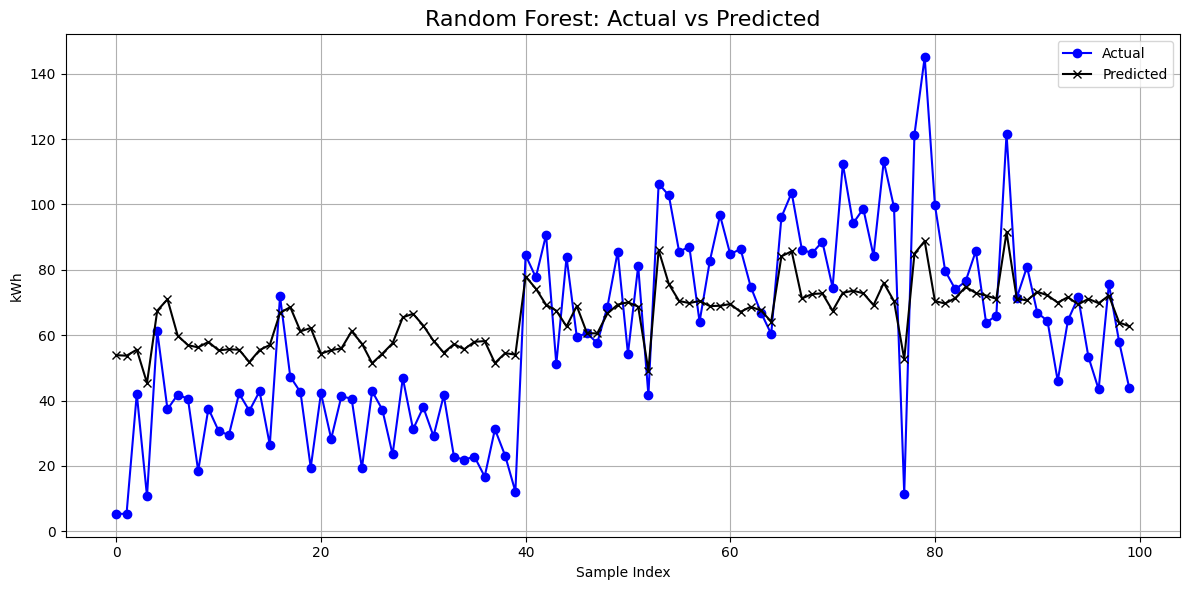

In [121]:
y_test_pred_rf = RF2_regressor.predict(x_test)
plot_actual_vs_predicted(y_test, y_test_pred_rf, "Random Forest: Actual vs Predicted")

In [122]:
import numpy as np
import matplotlib.pyplot as plt

def plot_prediction_parity(y_true, y_pred, title="Prediction Parity"):
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, s=14, alpha=0.5)
    lo = min(np.min(y_true), np.min(y_pred))
    hi = max(np.max(y_true), np.max(y_pred))
    plt.plot([lo, hi], [lo, hi], 'k--', lw=1)   # 45° line
    plt.xlim(lo, hi); plt.ylim(lo, hi)
    plt.title(title)
    plt.xlabel("Actual kWh"); plt.ylabel("Predicted kWh")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

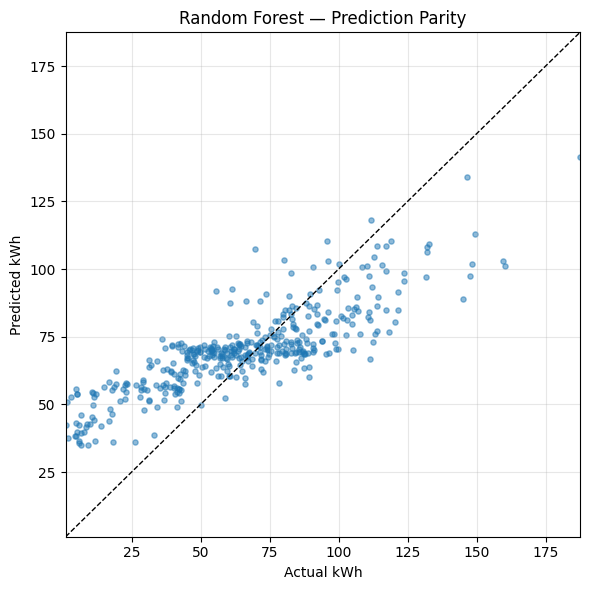

In [123]:
y_test_pred_rf = RF2_regressor.predict(x_test)
plot_prediction_parity(y_test, y_test_pred_rf, "Random Forest — Prediction Parity")

XG Boost Regressor

In [124]:
# Importing numpy for numerical operations
import numpy as np

# Importing XGBRegressor from xgboost (a gradient boosting model that builds trees sequentially)
from xgboost import XGBRegressor

# Importing GridSearchCV for hyperparameter tuning with cross-validation
# Importing TimeSeriesSplit as an option for chronological (time-series) data splits
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# Importing metrics to evaluate model performance:
# r2_score: goodness of fit (1 = perfect fit)
# mean_squared_error: used for RMSE
# mean_absolute_error: average absolute error
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


In [125]:
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Base model inside a Pipeline with StandardScaler
xgb_base = Pipeline([
    ("scaler", StandardScaler()),
    ("xgb", XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
        tree_method="hist"
    ))
])

# Hyperparameter grid (note the xgb__ prefixes)
Hparameters_XGB = {
    "xgb__n_estimators":     [800, 900, 1000, 1100],
    "xgb__max_depth":        [5, 6, 7, 8],
    "xgb__learning_rate":    [0.03, 0.07],
    "xgb__subsample":        [0.7, 1.0],
    "xgb__colsample_bytree": [0.8, 1.0],
    "xgb__min_child_weight": [5, 7],
    "xgb__reg_lambda":       [0, 1]
}

# Time-aware CV
cv = TimeSeriesSplit(n_splits=3)

# Grid Search on TRAIN only
grid_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=Hparameters_XGB,
    scoring="r2",
    cv=cv,
    n_jobs=-1,
    verbose=0
)

# Fit with raw X (scaler is inside the pipeline)
grid_xgb.fit(x_train, y_train)

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=3, test_size=None),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('xgb',
                                        XGBRegressor(base_score=None,
                                                     booster=None,
                                                     callbacks=None,
                                                     colsample_bylevel=None,
                                                     colsample_bynode=None,
                                                     colsample_bytree=None,
                                                     device=None,
                                                     early_stopping_rounds=None,
                                                     enable_categorical=False,
                                                     eval_metric=None...
                                                     monotone_constraints=None,
                                                     multi_strategy=None,
                                                     n_estimators=None,
                                                     n_jobs=-1,
                                                     num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'xgb__colsample_bytree': [0.8, 1.0],
                         'xgb__learning_rate': [0.03, 0.07],
                         'xgb__max_depth': [5, 6, 7, 8],
                         'xgb__min_child_weight': [5, 7],
                         'xgb__n_estimators': [800, 900, 1000, 1100],
                         'xgb__reg_lambda': [0, 1],
                         'xgb__subsample': [0.7, 1.0]},
             scoring='r2')

In [126]:
best_xgb_pipe = grid_xgb.best_estimator_
print("Best params:", grid_xgb.best_params_)


Best params: {'xgb__colsample_bytree': 1.0, 'xgb__learning_rate': 0.07, 'xgb__max_depth': 5, 'xgb__min_child_weight': 5, 'xgb__n_estimators': 800, 'xgb__reg_lambda': 0, 'xgb__subsample': 1.0}


In [127]:
# Evaluate
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Train
y_train_pred = best_xgb_pipe.predict(x_train)
print("Train R²:", r2_score(y_train, y_train_pred))
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("Train MAE:", mean_absolute_error(y_train, y_train_pred))

Train R²: 0.9980004308728494
Train RMSE: 1.6408407700120875
Train MAE: 1.1954026069354415


In [128]:
# confirm the tuned pipeline is using the best params from the grid
best_params = grid_xgb.best_params_
print("Best params (grid):", best_params)

used = best_xgb_pipe.get_params()  # pipeline params include 'xgb__...' keys
ok = all(used.get(k) == v for k, v in best_params.items())
print("Matches best params?", ok)

Best params (grid): {'xgb__colsample_bytree': 1.0, 'xgb__learning_rate': 0.07, 'xgb__max_depth': 5, 'xgb__min_child_weight': 5, 'xgb__n_estimators': 800, 'xgb__reg_lambda': 0, 'xgb__subsample': 1.0}
Matches best params? True


In [129]:
# R² score (coefficient of determination) for validation data
# Closer to 1 means better predictive performance
y_val_pred_xgb = best_xgb_pipe.predict(x_val)
r2_val_xgb = r2_score(y_val, y_val_pred_xgb)

# RMSE (Root Mean Squared Error) for validation predictions
# Penalizes large prediction errors more heavily
rmse_val_xgb = np.sqrt(mean_squared_error(y_val, y_val_pred_xgb))

# MAE (Mean Absolute Error) for validation predictions
# Measures average absolute error in same units as target
mae_val_xgb = mean_absolute_error(y_val,y_val_pred_xgb)


# Print metrics for validation set ---
print("XG Boost Regressor - Validate R²:", r2_val_xgb)
print("XG Boost Regressor - Validate RMSE:", rmse_val_xgb)
print("XG Boost Regressor - Validate MAE:", mae_val_xgb)


XG Boost Regressor - Validate R²: 0.6900648685518281
XG Boost Regressor - Validate RMSE: 16.741824184879313
XG Boost Regressor - Validate MAE: 13.489757101040805


In [130]:
# R² score (coefficient of determination) for validation data
# Closer to 1 means better predictive performance
y_test_pred_xgb = best_xgb_pipe.predict(x_test)
r2_test_xgb = r2_score(y_test, y_test_pred_xgb)

# RMSE (Root Mean Squared Error) for validation predictions
# Penalizes large prediction errors more heavily
rmse_test_xgb = np.sqrt(mean_squared_error(y_test, y_test_pred_xgb))

# MAE (Mean Absolute Error) for validation predictions
# Measures average absolute error in same units as target
mae_test_xgb = mean_absolute_error(y_test,y_test_pred_xgb)


# Print metrics for validation set ---
print("XG Boost Regressor - Test R²:", r2_test_xgb)
print("XG Boost Regressor - Test RMSE:", rmse_test_xgb)
print("XG Boost Regressor - Test MAE:", mae_test_xgb)

XG Boost Regressor - Test R²: 0.6119744102342957
XG Boost Regressor - Test RMSE: 20.190615863728095
XG Boost Regressor - Test MAE: 15.607975788299674


In [131]:
import pandas as pd

# get the fitted XGBRegressor from your pipeline
xgb = best_xgb_pipe.named_steps["xgb"]

# make a ranked list of importances using your training column names
fi = pd.Series(xgb.feature_importances_, index=x_train.columns).sort_values(ascending=False)

# print top N
N = 20
print("Top features (by importance):")
for i, (name, val) in enumerate(fi.head(N).items(), 1):
    print(f"{i:2d}. {name} — {val:.4f}")


Top features (by importance):
 1. load_kwh — 0.2550
 2. loc_WEBSTER #2 — 0.1008
 3. loc_WEBSTER #1 — 0.0881
 4. loc_HIGH #1 — 0.0716
 5. loc_MPL #3 — 0.0670
 6. loc_BRYANT #5 — 0.0406
 7. loc_MPL #2 — 0.0347
 8. loc_TED THOMPSON #1 — 0.0334
 9. loc_BRYANT #6 — 0.0268
10. Year — 0.0256
11. loc_CAMBRIDGE #1 — 0.0201
12. loc_BRYANT #1 — 0.0174
13. loc_HIGH #3 — 0.0171
14. loc_MPL #1 — 0.0156
15. loc_HAMILTON #1 — 0.0116
16. loc_HAMILTON #2 — 0.0103
17. loc_MPL #6 — 0.0102
18. loc_BRYANT #4 — 0.0101
19. loc_MPL #5 — 0.0092
20. loc_RINCONADA LIB 1 — 0.0089


In [132]:
import numpy as np
import matplotlib.pyplot as plt

def plot_actual_vs_predicted(y_true, y_pred, title="Actual vs Predicted"):
    plt.figure(figsize=(12, 6))
    n = min(100, len(y_true))              # show first 100 points
    idx = np.arange(n)
    plt.plot(idx, y_true[:n], label='Actual', marker='o', color='blue')
    plt.plot(idx, y_pred[:n], label='Predicted', marker='x', color='black')
    plt.title(title, fontsize=16)
    plt.xlabel('Sample Index')
    plt.ylabel('kWh')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

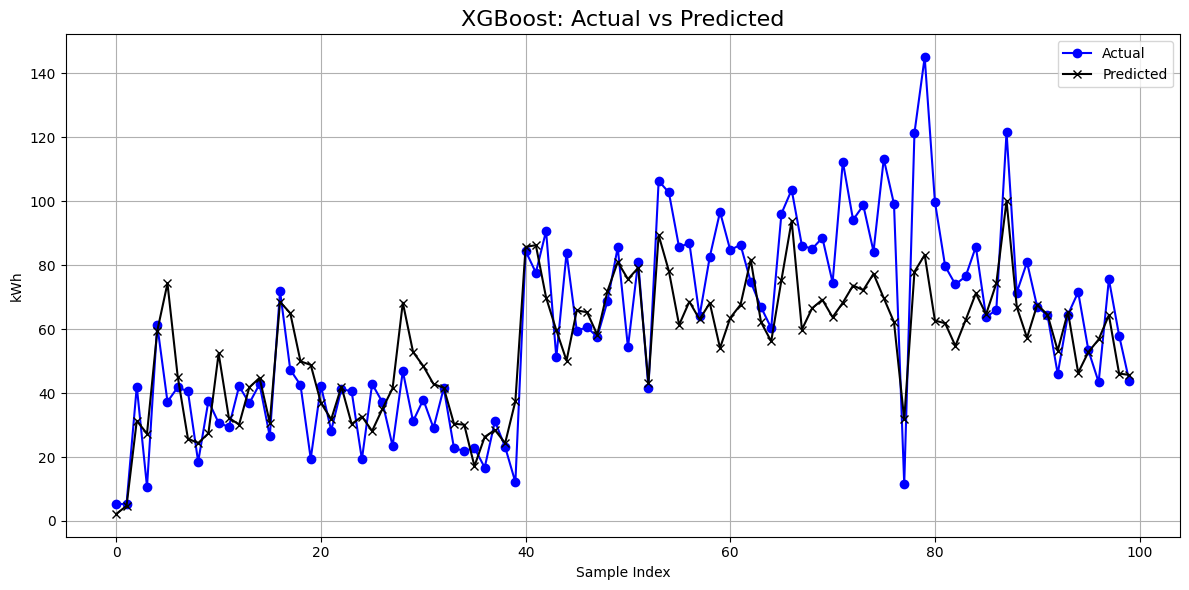

In [133]:
y_test_pred_xgb = best_xgb_pipe.predict(x_test)
plot_actual_vs_predicted(y_test, y_test_pred_xgb, "XGBoost: Actual vs Predicted")

In [134]:
import numpy as np
import matplotlib.pyplot as plt

def plot_prediction_parity(y_true, y_pred, title="Prediction Parity"):
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, s=14, alpha=0.5)
    lo = min(np.min(y_true), np.min(y_pred))
    hi = max(np.max(y_true), np.max(y_pred))
    plt.plot([lo, hi], [lo, hi], 'k--', lw=1)   # 45° line
    plt.xlim(lo, hi); plt.ylim(lo, hi)
    plt.title(title)
    plt.xlabel("Actual kWh"); plt.ylabel("Predicted kWh")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

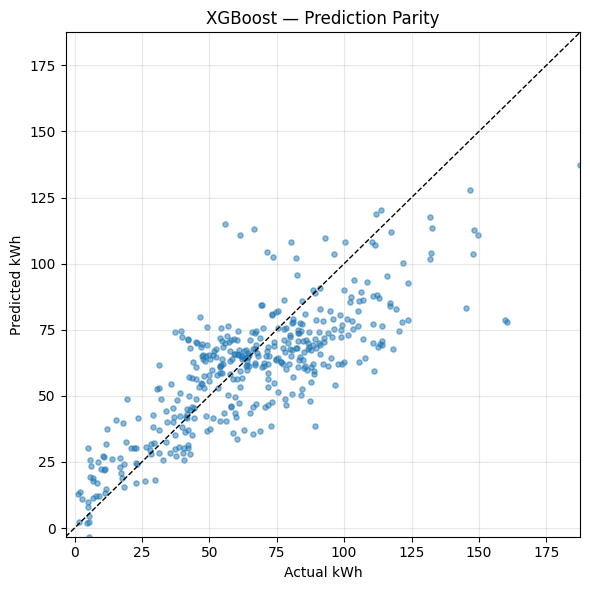

In [135]:
y_test_pred_xgb = best_xgb_pipe.predict(x_test)
plot_prediction_parity(y_test, y_test_pred_xgb, "XGBoost — Prediction Parity")

Neural Network

In [136]:
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Default Neural Network (MLP) with StandardScaler inside
nn = Pipeline([
    ("scaler", StandardScaler()),
    ("nn", MLPRegressor(random_state=42, max_iter=1000))  # simple, robust default
])

# Fit on TRAIN only (pass raw X)
nn.fit(x_train, y_train)

# Train metrics (same style)
y_train_pred_nn = nn.predict(x_train)
print("Train R²:", r2_score(y_train, y_train_pred_nn))
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred_nn)))
print("Train MAE:", mean_absolute_error(y_train, y_train_pred_nn))


Train R²: 0.9364513548650515
Train RMSE: 9.250205370704457
Train MAE: 6.895631562830645


In [137]:
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Pipeline: StandardScaler + MLP (Neural Network)
nn_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("nn", MLPRegressor(random_state=42, max_iter=2000, early_stopping=True))
])

# Hyperparameter search space (simple & effective)
param_space = {
    "nn__hidden_layer_sizes": [(64,), (64,32), (128,64), (64,64,32)],
    "nn__activation": ["relu", "tanh"],
    "nn__alpha": [1e-5, 1e-4, 1e-3, 1e-2],          # L2 regularization
    "nn__learning_rate_init": [1e-3, 3e-3, 1e-2],
    "nn__batch_size": ["auto", 64, 128]
}

# Randomized search on TRAIN only
nn_search = RandomizedSearchCV(
    estimator=nn_pipe,
    param_distributions=param_space,
    n_iter=25,
    scoring="neg_root_mean_squared_error",
    cv=5,
    random_state=42,
    n_jobs=-1,
    refit=True
)
nn_search.fit(x_train, y_train)

best_nn_pipe = nn_search.best_estimator_
print("Best params:", nn_search.best_params_)

Best params: {'nn__learning_rate_init': 0.001, 'nn__hidden_layer_sizes': (64,), 'nn__batch_size': 64, 'nn__alpha': 0.001, 'nn__activation': 'relu'}


In [138]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# use your fitted model here (pipeline with StandardScaler inside)
nn_regressor = best_nn_pipe   # <- change if your variable name differs

#  Train metrics
y_train_pred = nn_regressor.predict(x_train)  # raw X; pipeline scales inside
r2_train_NN   = r2_score(y_train, y_train_pred)
rmse_train_NN = np.sqrt(mean_squared_error(y_train, y_train_pred))
mae_train_NN  = mean_absolute_error(y_train, y_train_pred)
print("Train R²:", r2_train_NN)
print("Train RMSE:", rmse_train_NN)
print("Train MAE:", mae_train_NN)

# Validate metrics
y_val_pred_NN = nn_regressor.predict(x_val)   # raw X; pipeline scales inside
r2_val_NN   = r2_score(y_val, y_val_pred_NN)
rmse_val_NN = np.sqrt(mean_squared_error(y_val, y_val_pred_NN))
mae_val_NN  = mean_absolute_error(y_val, y_val_pred_NN)
print("Val R²:", r2_val_NN)
print("Val RMSE:", rmse_val_NN)
print("Val MAE:", mae_val_NN)

Train R²: 0.893244247729942
Train RMSE: 11.989301167068625
Train MAE: 9.205926239355676
Val R²: 0.5592556613484364
Val RMSE: 19.964606041060694
Val MAE: 16.410057524890785


In [139]:
# Performance evealuation on test set for Neural network
y_test_pred_NN = nn_regressor.predict(x_test)   # raw X; pipeline scales inside
r2_test_NN   = r2_score(y_test, y_test_pred_NN)
rmse_test_NN = np.sqrt(mean_squared_error(y_test, y_test_pred_NN))
mae_test_NN  = mean_absolute_error(y_test, y_test_pred_NN)
print("Test R²:", r2_test_NN)
print("Test RMSE:", rmse_test_NN)
print("Test MAE:", mae_test_NN)

Test R²: 0.48985251810283537
Test RMSE: 23.150866788273664
Test MAE: 18.59777327954581


In [140]:
import numpy as np
import matplotlib.pyplot as plt

def plot_actual_vs_predicted(y_true, y_pred, title="Actual vs Predicted"):
    plt.figure(figsize=(12, 6))
    n = min(100, len(y_true))              # show first 100 points
    idx = np.arange(n)
    plt.plot(idx, y_true[:n], label='Actual', marker='o', color='blue')
    plt.plot(idx, y_pred[:n], label='Predicted', marker='x', color='black')
    plt.title(title, fontsize=16)
    plt.xlabel('Sample Index')
    plt.ylabel('kWh')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

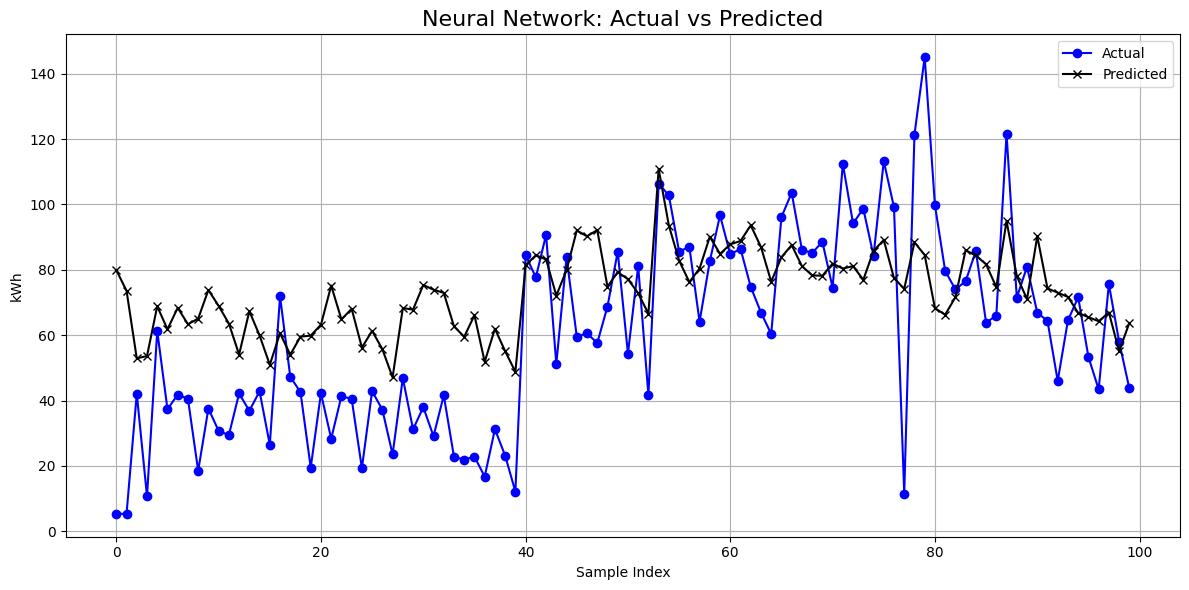

In [141]:
y_test_pred_nn = nn_regressor.predict(x_test)
plot_actual_vs_predicted(y_test, y_test_pred_nn, "Neural Network: Actual vs Predicted")

In [142]:
import numpy as np
import matplotlib.pyplot as plt

def plot_prediction_parity(y_true, y_pred, title="Prediction Parity"):
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, s=14, alpha=0.5)
    lo = min(np.min(y_true), np.min(y_pred))
    hi = max(np.max(y_true), np.max(y_pred))
    plt.plot([lo, hi], [lo, hi], 'k--', lw=1)   # 45° line
    plt.xlim(lo, hi); plt.ylim(lo, hi)
    plt.title(title)
    plt.xlabel("Actual kWh"); plt.ylabel("Predicted kWh")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

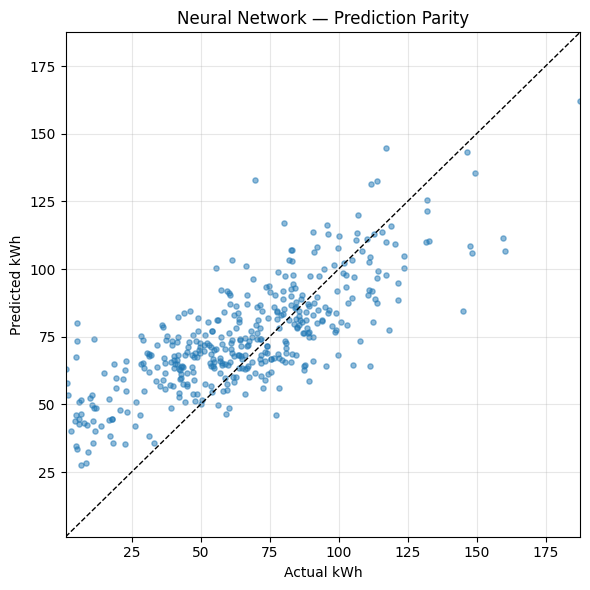

In [143]:
y_test_pred_nn = nn_regressor.predict(x_test)
plot_prediction_parity(y_test, y_test_pred_nn, "Neural Network — Prediction Parity")